In [48]:
from pathlib import Path          
import numpy as np                
import pandas as pd               
import matplotlib.pyplot as plt   
from astropy.io import fits       
from astropy.time import Time

# paths used by every cell below (defined here so the notebook runs top to bottom)
DATA_DIR = Path("..") / "database"
OUTPUT_DIR = Path("..") / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


In [49]:
x = DATA_DIR / "metadata" / "observations.csv"
df = pd.read_csv(x)
df

,filename,datetime,fits_url,fov,exposure,filter,target,telescope,site,user,is_calibration,session_id,filepath,download_status,file_size
0,Dark-C-260806124514,2026-08-06 12:45:14,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-06\Dark-C-260806124514.fits,already_exists,656640
1,Dark-C-260806125119,2026-08-06 12:51:19,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-06\Dark-C-260806125119.fits,already_exists,656640
2,Dark-C-260807123949,2026-08-07 12:39:49,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-07\Dark-C-260807123949.fits,already_exists,656640
3,Dark-C-260807124553,2026-08-07 12:45:53,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-07\Dark-C-260807124553.fits,already_exists,656640
4,Dark-C-260808123758,2026-08-08 12:37:58,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-08\Dark-C-260808123758.fits,already_exists,656640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1736,WASP-2260824082715,2026-08-24 08:27:15,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Clear,WASP-2,Cecilia,AZ,moguest,False,session_01,observations\2026-08-24\WASP-2\session_01\WASP...,downloaded,656640
1737,WASP-2260824083015,2026-08-24 08:30:15,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Clear,WASP-2,Cecilia,AZ,moguest,False,session_01,observations\2026-08-24\WASP-2\session_01\WASP...,downloaded,656640
1738,WASP-2260824083316,2026-08-24 08:33:16,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Clear,WASP-2,Cecilia,AZ,moguest,False,session_01,observations\2026-08-24\WASP-2\session_01\WASP...,downloaded,656640
1739,WASP-2260824083615,2026-08-24 08:36:15,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Clear,WASP-2,Cecilia,AZ,moguest,False,session_01,observations\2026-08-24\WASP-2\session_01\WASP...,downloaded,656640


In [50]:
df.describe()

,exposure,file_size
count,1741.0,1741.0
mean,60.0,656640.0
std,0.0,0.0
min,60.0,656640.0
25%,60.0,656640.0
50%,60.0,656640.0
75%,60.0,656640.0
max,60.0,656640.0


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1741 entries, 0 to 1740
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   filename         1741 non-null   str    
 1   datetime         1741 non-null   str    
 2   fits_url         1741 non-null   str    
 3   fov              1741 non-null   str    
 4   exposure         1741 non-null   float64
 5   filter           1741 non-null   str    
 6   target           1741 non-null   str    
 7   telescope        1741 non-null   str    
 8   site             1741 non-null   str    
 9   user             1741 non-null   str    
 10  is_calibration   1741 non-null   bool   
 11  session_id       1681 non-null   str    
 12  filepath         1741 non-null   str    
 13  download_status  1741 non-null   str    
 14  file_size        1741 non-null   int64  
dtypes: bool(1), float64(1), int64(1), str(12)
memory usage: 192.3 KB


In [57]:
DATA_DIR = Path("..") / "database"
all_fits = sorted(DATA_DIR.rglob("*.fits"))
science_files = [p for p in all_fits if "observations" in p.parts]
calibration_files = [p for p in all_fits if "calibration" in p.parts]

print("All FITS files:     ", len(all_fits))
print("Science images:     ", len(science_files))
print("Calibration images: ", len(calibration_files))

All FITS files:      1741
Science images:      1681
Calibration images:  60


In [61]:
example = science_files[0]
example


PosixPath('../database/observations/2026-08-06/TRES-1/session_01/TRES-1260806073422.fits')

In [62]:
rows = []
for p in science_files:
    _, night, target, session, filename = p.relative_to(DATA_DIR).parts
    rows.append({"night": night, "target": target, "session": session, "file": filename})
paths_df = pd.DataFrame(rows)

print("Different target stars:     ", paths_df["target"].nunique())
print("Nights (star + date pairs):  ", paths_df.groupby(["target", "night"]).ngroups)

# One row per star: how many images and how many different nights
per_target = (paths_df.groupby("target")
              .agg(images=("file", "count"), nights=("night", "nunique"))
              .sort_values("images", ascending=False))
per_target

Different target stars:      8
Nights (star + date pairs):   22


,images,nights
target,,
TRES-5,427,6
CoRoT-2,346,4
TRES-3,261,4
Qatar-1,222,3
WASP-2,155,2
HATP-10,93,1
TRES-1,91,1
WASP-10,86,1


In [64]:
meta = pd.read_csv(DATA_DIR / "metadata" / "observations.csv")
print("rows, columns:", meta.shape)
meta.head()

rows, columns: (1741, 15)


,filename,datetime,fits_url,fov,exposure,filter,target,telescope,site,user,is_calibration,session_id,filepath,download_status,file_size
0,Dark-C-260806124514,2026-08-06 12:45:14,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-06\Dark-C-260806124514.fits,already_exists,656640
1,Dark-C-260806125119,2026-08-06 12:51:19,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-06\Dark-C-260806125119.fits,already_exists,656640
2,Dark-C-260807123949,2026-08-07 12:39:49,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-07\Dark-C-260807123949.fits,already_exists,656640
3,Dark-C-260807124553,2026-08-07 12:45:53,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-07\Dark-C-260807124553.fits,already_exists,656640
4,Dark-C-260808123758,2026-08-08 12:37:58,https://mo-www.cfa.harvard.edu/ImageDirectory/...,Main,60.0,Opaque,Calibration,Cecilia,AZ,moguest,True,NaN,calibration\2026-08-08\Dark-C-260808123758.fits,already_exists,656640


In [18]:
meta["filter"].value_counts()

filter
Clear     1681
Opaque      60
Name: count, dtype: int64

In [19]:
# Step 4b: how many different values does each column have?
# A column with only 1 value is the same for every image, so it cannot help a model.
meta.nunique().sort_values()

fov                   1
exposure              1
telescope             1
site                  1
user                  1
session_id            1
file_size             1
filter                2
is_calibration        2
download_status       2
target                9
filename           1741
datetime           1741
fits_url           1741
filepath           1741
dtype: int64

In [20]:
# Step 4c: does the metadata agree with the files on disk?
from_disk = paths_df["target"].value_counts()
from_meta = meta.loc[~meta["is_calibration"], "target"].value_counts()

check = pd.DataFrame({"on_disk": from_disk, "in_metadata": from_meta})
check["match"] = check["on_disk"] == check["in_metadata"]
check

,on_disk,in_metadata,match
target,,,
TRES-5,427,427,True
CoRoT-2,346,346,True
TRES-3,261,261,True
Qatar-1,222,222,True
WASP-2,155,155,True
HATP-10,93,93,True
TRES-1,91,91,True
WASP-10,86,86,True


## Step 5 — Open one FITS file

A FITS file can contain several parts called **HDUs** (Header Data Units). Our files have one HDU: a header plus an image.

In [21]:
# Step 5a: open one science image — the middle image of the CoRoT-2 night on 2026-08-09 (a clear night)
corot2_night = [p for p in science_files if p.parts[-3] == "CoRoT-2" and p.parts[-4] == "2026-08-09"]
sample_path = corot2_night[len(corot2_night) // 2]
with fits.open(sample_path) as hdul:
    hdul.info()                            # how many HDUs and what is inside each one
    header = hdul[0].header                # the text labels
    image = hdul[0].data.astype(float)     # the pixel grid as decimal numbers

print("\nImage shape (rows, columns):", image.shape)

Filename: ../database/observations/2026-08-09/CoRoT-2/session_01/CoRoT-2260809072715.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      71   (650, 500)   int16   

Image shape (rows, columns): (500, 650)


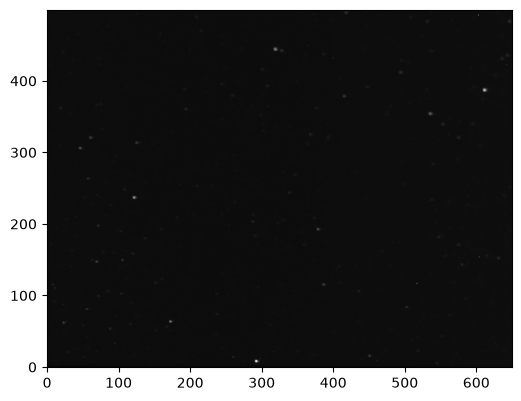

In [24]:
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray", origin="lower")

In [22]:
# Step 5b: print the full header (scroll through it once, it is worth it)
header

SIMPLE  =                    T / Conforms to FITS Standard                      
BITPIX  =                   16  / 12 Bits per pixel, in 16 bit word             
NAXIS   =                    2 / Table is a two-dimensional matrix              
NAXIS1  =                  650 / Width of table row in bytes                    
NAXIS2  =                  500 / Number of rows in table                        
EQUINOX = 2000.0 / Epoch of celestial coordinate system used                    
FILENAME= 'CoRoT-2260809072715.FIT' / FILENAME + YYMMDDhhmmss(UTC)              
DATE-OBS= '2026-08-09T00:27:15.858-0700' / Start date & time of observation, LT 
DATE-END= '2026-08-09T00:28:17.606-0700' / End date & time of observation, LT   
LST-OBS = '21:14:57' / Local mean sidereal (LST) time at start                  
UT-OBS  = '2026-08-09T07:27:15.858-0000' / Universal Time (UT) at start of obs. 
MJD-OBS = 61261.311 / Modified Julian Date (MJD) at start of observation        
OBJECT  = 'CoRoT-2 ' / Name 

In [25]:
# Step 5c: the header fields we will actually use, with their meaning
important_keys = {
    "OBJECT":   "name of the star the telescope pointed at",
    "UT-OBS":   "start time of the photo in Universal Time (precise to milliseconds)",
    "MJD-OBS":  "the same time as a number of days (but rounded, see Step 8)",
    "EXPTIME":  "exposure time in seconds (how long the shutter was open)",
    "FILTER":   "filter in front of the camera (Clear = no color filter)",
    "TELALT":   "how high the telescope pointed above the horizon, in degrees (90 = straight up)",
    "WEATHER":  "estimated sky condition: 0 = poor, 100 = excellent",
    "DATAMAX":  "largest possible pixel value (12-bit camera = 4095)",
    "IM_SCALE": "how much sky one pixel covers, in arc-seconds",
}
pd.DataFrame([{"key": k, "value": header.get(k), "meaning": v} for k, v in important_keys.items()])

,key,value,meaning
0,OBJECT,CoRoT-2,name of the star the telescope pointed at
1,UT-OBS,2026-08-09T07:27:15.858-0000,start time of the photo in Universal Time (pre...
2,MJD-OBS,61261.311,the same time as a number of days (but rounded...
3,EXPTIME,60.0,exposure time in seconds (how long the shutter...
4,FILTER,Clear,filter in front of the camera (Clear = no colo...
5,TELALT,50.683,how high the telescope pointed above the horiz...
6,WEATHER,100,"estimated sky condition: 0 = poor, 100 = excel..."
7,DATAMAX,4095.0,largest possible pixel value (12-bit camera = ...
8,IM_SCALE,5.0,"how much sky one pixel covers, in arc-seconds"


## Step 6 — Look at the image

Most pixels are dark sky and only a few pixels are stars. If we display the raw numbers, almost everything looks black,
so we limit the color scale between a low and a high percentile of the pixel values — this makes faint stars visible.

**Important:** the raw image also contains the camera's own signal — look at the bright gradient on the right side of the dark frame. If we measure star brightness without removing it, stars on the right side will look brighter than they really are. So we subtract a dark frame taken on the same date.

The telescope was pointed at the target, so **the target star should be near the center** of the image.

In [26]:
# Step 6a: helper that returns the dark frame for a given night
# Each date has 2 dark frames; we take their median (the middle value of every pixel) to reduce noise.
# One night (2026-09-04) has no dark from the same date, so we use the closest date instead.
dark_dates = sorted({p.parts[-2] for p in calibration_files})

def load_dark(night):
    closest = min(dark_dates, key=lambda d: abs(pd.Timestamp(d) - pd.Timestamp(night)))
    dark_paths = [p for p in calibration_files if p.parts[-2] == closest]
    return np.median([fits.getdata(p).astype(float) for p in dark_paths], axis=0)

sample_night = sample_path.parts[-4]
dark = load_dark(sample_night)
calibrated = image - dark          # remove the camera's own signal
print("Dark frames available for", len(dark_dates), "dates")

Dark frames available for 30 dates


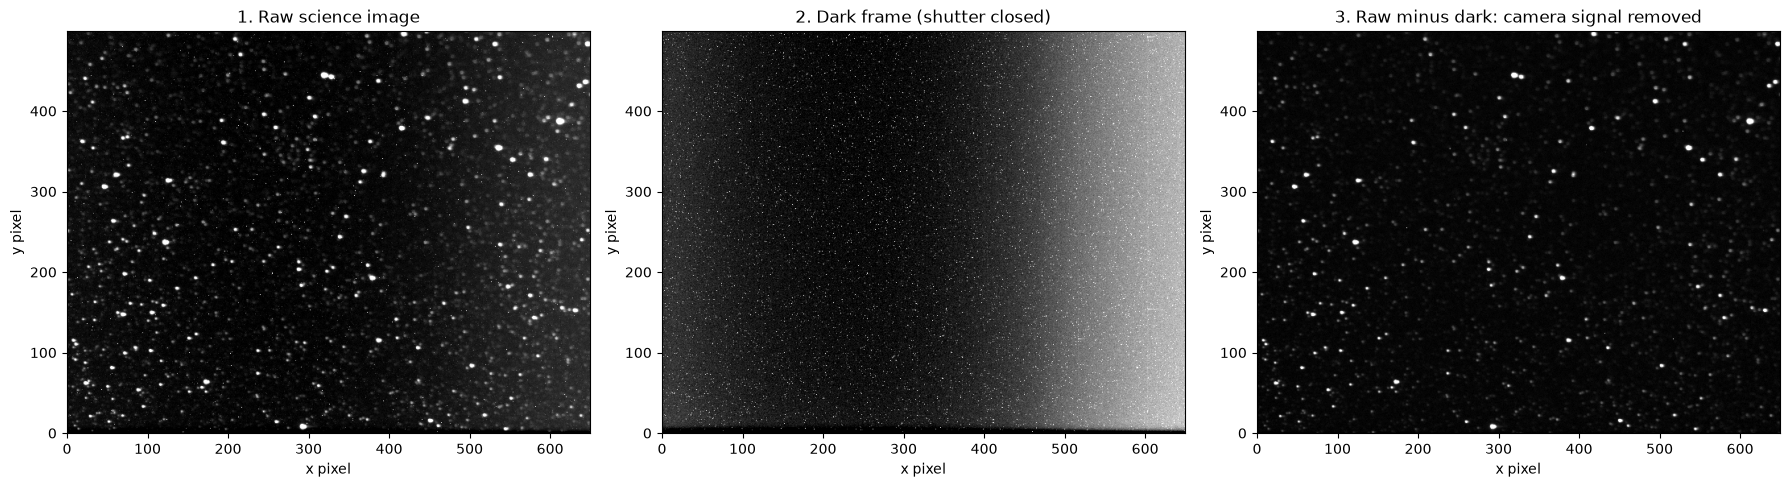

In [27]:
# Step 6b: raw image, dark frame, and raw minus dark
def show_image(img, title, ax, low_pct=5, high_pct=99.5):
    low, high = np.percentile(img, [low_pct, high_pct])   # color limits that make stars visible
    ax.imshow(img, cmap="gray", origin="lower", vmin=low, vmax=high)
    ax.set_title(title)
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
show_image(image, "1. Raw science image", axes[0])
show_image(dark, "2. Dark frame (shutter closed)", axes[1])
show_image(calibrated, "3. Raw minus dark: camera signal removed", axes[2], low_pct=1, high_pct=99.8)
plt.tight_layout()
plt.show()

In [28]:
# Step 6c: compare the typical pixel values
print(f"Raw image  -> median pixel: {np.median(image):7.1f}")
print(f"Dark frame -> median pixel: {np.median(dark):7.1f}")
print(f"Raw - dark -> median pixel: {np.median(calibrated):7.1f}   <- the real sky signal is small")

Raw image  -> median pixel:   406.0
Dark frame -> median pixel:   376.0
Raw - dark -> median pixel:    29.0   <- the real sky signal is small


### Clear night vs. cloudy night

Now the same processing on a night with a weather score of 0 (TRES-1, 2026-08-06). Clouds block the starlight, so almost nothing is left after subtracting the dark.

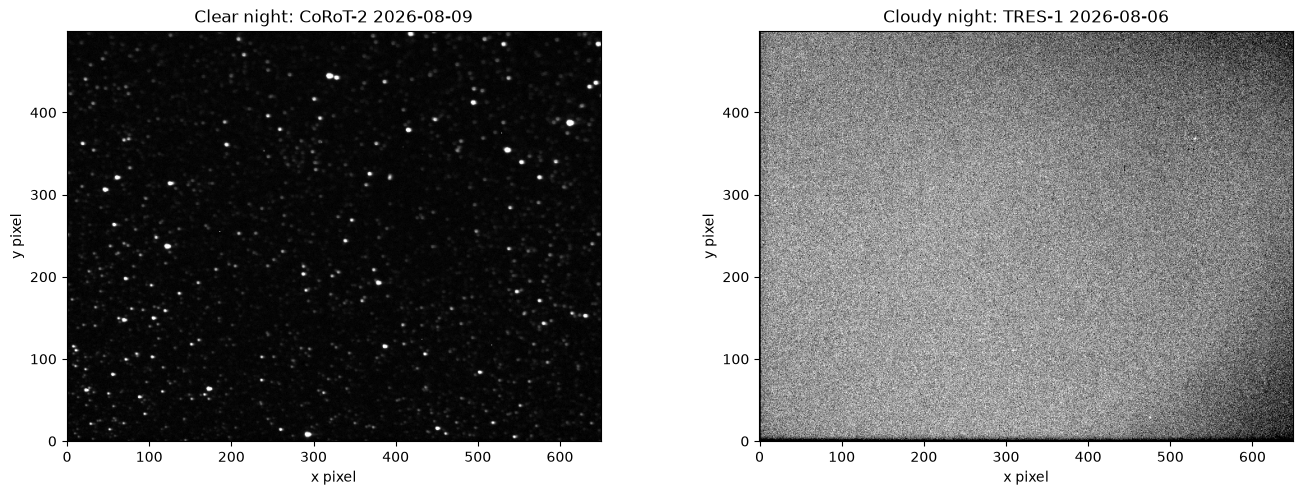

In [29]:
# Step 6d: compare a clear night with a cloudy night
tres1_night = [p for p in science_files if p.parts[-3] == "TRES-1"]
cloudy_path = tres1_night[len(tres1_night) // 2]
cloudy = fits.getdata(cloudy_path).astype(float) - load_dark(cloudy_path.parts[-4])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
show_image(calibrated, f"Clear night: {sample_path.parts[-3]} {sample_night}", axes[0], 1, 99.8)
show_image(cloudy, f"Cloudy night: {cloudy_path.parts[-3]} {cloudy_path.parts[-4]}", axes[1], 1, 99.8)
plt.tight_layout()
plt.show()

In [30]:
# find the brightest pixel in the dark-subtracted image and print the numbers around it
row, col = np.unravel_index(np.argmax(calibrated), calibrated.shape)
print("brightest pixel at row", row, "column", col)
print(calibrated[row-4:row+5, col-4:col+5].round())

brightest pixel at row 8 column 292
[[  32.   36.   36.   45.   52.   58.   52.   38.   33.]
 [  36.   38.   55.   78.  104.  112.   93.   68.   51.]
 [  38.   52.   92.  228.  416.  424.  294.  182.  114.]
 [  44.   63.  185. 1045. 2624. 2364. 1260.  743.  388.]
 [  47.   82.  360. 2471. 3722. 3722. 2118. 1238.  590.]
 [  41.   75.  386. 2206. 3722. 3520. 1616.  988.  497.]
 [  42.   58.  178.  704. 1244.  943.  464.  312.  164.]
 [  34.   46.   70.  130.  166.  140.  104.   78.   51.]
 [  36.   38.   44.   52.   56.   60.   50.   42.   40.]]


In [31]:
print(calibrated[100:105, 100:105].round())

[[ 28.  28.  35.  46.  46.]
 [ 30.  34.  57. 132. 160.]
 [ 27.  40. 114. 343. 383.]
 [ 29.  45. 131. 297. 350.]
 [ 29.  40.  73. 150. 154.]]


In [32]:
# Test: is the "Opaque" filter really 100% opaque?
# The 2 darks of each date are taken ~6 minutes apart, close to sunrise.
# If light leaks through the filter, the later dark should be consistently brighter.
dark_info = []
for p in calibration_files:
    with fits.open(p) as hdul:
        h = hdul[0].header
        d = hdul[0].data.astype(float)
    dark_info.append({
        "date": p.parts[-2],
        "time_ut": h["UT-OBS"][11:19],
        "median": float(np.median(d)),
        "max": int(d.max()),
        "camera_temp_k": float(h["CAMTEMP"]),
    })

dark_info = pd.DataFrame(dark_info).sort_values(["date", "time_ut"]).reset_index(drop=True)

# For each date: how much brighter is the second dark than the first?
dark_info["order"] = dark_info.groupby("date").cumcount() + 1
pairs = dark_info.pivot(index="date", columns="order", values="median")
pairs["difference"] = pairs[2] - pairs[1]
print(pairs["difference"].describe().round(2))
dark_info

count    30.00
mean     -0.93
std       0.94
min      -3.00
25%      -1.00
50%      -1.00
75%      -1.00
max       3.00
Name: difference, dtype: float64


,date,time_ut,median,max,camera_temp_k,order
0,2026-08-06,12:45:14,362.0,2821,276.0,1
1,2026-08-06,12:51:19,361.0,2819,277.0,2
2,2026-08-07,12:39:49,373.0,3175,280.0,1
3,2026-08-07,12:45:53,372.0,3258,280.0,2
4,2026-08-08,12:37:58,369.0,2949,279.0,1
5,2026-08-08,12:44:01,368.0,2907,279.0,2
6,2026-08-09,05:20:54,376.0,3238,282.0,1
7,2026-08-09,05:24:57,376.0,3263,282.0,2
8,2026-08-10,12:35:29,365.0,2640,278.0,1
9,2026-08-10,12:41:33,363.0,2608,277.0,2


## Step 7 — One row per image for the whole dataset

Now we read the header of **every** science image and compute two simple numbers from its pixels:

- `sky_median`: the typical pixel value → tells us how bright the sky background is (twilight, moon, clouds).
- `n_saturated`: how many pixels hit the camera limit (4095) → saturated pixels give wrong brightness.

This reads 1,681 files, so it takes around a minute.

In [33]:
# Step 7a: read all science images (header + two pixel statistics)
records = []
for i, p in enumerate(science_files):
    with fits.open(p) as hdul:
        h = hdul[0].header
        data = hdul[0].data
        records.append({
            "path": p.relative_to(DATA_DIR).as_posix(),   # forward slashes work on Mac, Linux and Windows
            "night": p.parts[-4],
            "target": h["OBJECT"].strip(),
            "time_ut": h["UT-OBS"][:23],                  # keep '2026-08-10T06:06:40.229', drop the '-0000' ending
            "mjd_header": float(h["MJD-OBS"]),
            "exptime_s": float(h["EXPTIME"]),
            "filter": h["FILTER"].strip(),
            "altitude_deg": float(h["TELALT"]),
            "weather": int(h["WEATHER"]),
            "sky_median": float(np.median(data)),
            "max_pixel": int(data.max()),
            "n_saturated": int((data >= h["DATAMAX"]).sum()),
        })
    if (i + 1) % 250 == 0:
        print(f"read {i + 1} / {len(science_files)} files")

frames = pd.DataFrame(records)

# Precise time as a number of days, computed from the millisecond UT-OBS text
frames["mjd"] = Time(frames["time_ut"].tolist(), format="isot", scale="utc").mjd

frames = frames.sort_values(["target", "mjd"]).reset_index(drop=True)
print("done:", frames.shape)
frames.head()

read 250 / 1681 files
read 500 / 1681 files
read 750 / 1681 files
read 1000 / 1681 files
read 1250 / 1681 files
read 1500 / 1681 files
done: (1681, 13)


,path,night,target,time_ut,mjd_header,exptime_s,filter,altitude_deg,weather,sky_median,max_pixel,n_saturated,mjd
0,observations/2026-08-09/CoRoT-2/session_01/CoR...,2026-08-09,CoRoT-2,2026-08-09T05:18:53.898,61261.221,60.0,Clear,59.306,100,410.0,4095,1,61261.221457
1,observations/2026-08-09/CoRoT-2/session_01/CoR...,2026-08-09,CoRoT-2,2026-08-09T05:22:56.649,61261.224,60.0,Clear,59.451,100,412.0,4095,2,61261.224267
2,observations/2026-08-09/CoRoT-2/session_01/CoR...,2026-08-09,CoRoT-2,2026-08-09T05:26:58.583,61261.227,60.0,Clear,59.571,100,413.0,3810,0,61261.227067
3,observations/2026-08-09/CoRoT-2/session_01/CoR...,2026-08-09,CoRoT-2,2026-08-09T05:28:44.793,61261.228,60.0,Clear,59.617,100,412.0,3281,0,61261.228296
4,observations/2026-08-09/CoRoT-2/session_01/CoR...,2026-08-09,CoRoT-2,2026-08-09T05:30:31.115,61261.230,60.0,Clear,59.655,100,412.0,4095,1,61261.229527


In [34]:
# Step 7b: summary of every night (one row per star + date)
frames["minutes_since_previous"] = frames.groupby(["target", "night"])["mjd"].diff() * 24 * 60

nights = (frames.groupby(["target", "night"])
          .agg(n_images=("path", "count"),
               start_ut=("time_ut", "min"),
               hours=("mjd", lambda t: (t.max() - t.min()) * 24),
               cadence_min=("minutes_since_previous", "median"),
               biggest_gap_min=("minutes_since_previous", "max"),
               altitude_start=("altitude_deg", "first"),
               altitude_end=("altitude_deg", "last"),
               weather_mean=("weather", "mean"),
               frames_with_saturation=("n_saturated", lambda s: int((s > 0).sum())))
          .round(2))
nights

n_images                 start_ut  hours  cadence_min  \
target  night                                                               
CoRoT-2 2026-08-09        87  2026-08-09T05:18:53.898   4.29         2.99   
        2026-08-16        86  2026-08-16T04:40:02.011   4.29         3.01   
        2026-08-23        86  2026-08-23T03:57:58.009   4.29         3.01   
        2026-08-30        87  2026-08-30T03:18:36.985   4.49         3.00   
HATP-10 2026-09-05        93  2026-09-05T07:42:24.011   4.65         2.40   
Qatar-1 2026-08-18        75  2026-08-18T08:24:49.906   4.02         3.01   
        2026-08-21        74  2026-08-21T04:37:41.530   3.63         3.00   
        2026-08-28        73  2026-08-28T07:00:36.825   3.64         3.01   
TRES-1  2026-08-06        91  2026-08-06T07:34:22.622   5.06         3.01   
TRES-3  2026-08-10        70  2026-08-10T06:06:40.229   3.82         3.01   
        2026-08-14        51  2026-08-14T04:09:28.759   2.50         3.00   
        2026-08-27        70  2026-08-27T05:39:37.519   3.44         2.99   
        2026-08-31        70  2026-08-31T03:47:10.252   3.37         3.01   
TRES-5  2026-08-17        74  2026-08-17T09:17:50.399   5.17         3.01   
        2026-08-20        74  2026-08-20T08:24:56.775   3.93         3.01   
        2026-08-26        74  2026-08-26T06:44:46.938   3.61         3.01   
        2026-08-29        74  2026-08-29T05:52:50.942   3.62         3.01   
        2026-09-01        74  2026-09-01T05:00:38.463   3.64         3.01   
        2026-09-04        57  2026-09-04T04:10:43.762   2.78         3.01   
WASP-10 2026-08-08        86  2026-08-08T05:40:17.063   4.23         3.01   
WASP-2  2026-08-11        78  2026-08-11T06:54:33.864   3.85         3.00   
        2026-08-24        77  2026-08-24T04:52:31.321   3.78         3.01   

                    biggest_gap_min  altitude_start  altitude_end  \
target  night                                                       
CoRoT-2 2026-08-09             4.05           59.31         26.86   
        2026-08-16             6.00           58.74         29.19   
        2026-08-23             6.01           57.69         32.11   
        2026-08-30             6.57           56.60         32.01   
HATP-10 2026-09-05             7.97           40.50         80.29   
Qatar-1 2026-08-18             7.92           49.07         24.91   
        2026-08-21             3.02           55.14         48.88   
        2026-08-28             6.00           52.52         31.71   
TRES-1  2026-08-06             7.62           63.75          6.24   
TRES-3  2026-08-10             7.46           63.74         19.63   
        2026-08-14             3.88           82.43         54.14   
        2026-08-27             3.03           55.84         16.51   
        2026-08-31             3.03           74.87         35.21   
TRES-5  2026-08-17             8.27           47.38         11.21   
        2026-08-20             7.95           52.14         23.18   
        2026-08-26             3.03           59.25         34.98   
        2026-08-29             4.97           61.44         39.96   
        2026-09-01             3.03           62.14         44.88   
        2026-09-04             3.02           61.31         55.15   
WASP-10 2026-08-08             3.03           40.94         85.49   
WASP-2  2026-08-11             4.02           64.49         26.91   
        2026-08-24             3.02           61.93         42.27   

                    weather_mean  frames_with_saturation  
target  night                                             
CoRoT-2 2026-08-09        100.00                      64  
        2026-08-16         97.00                      60  
        2026-08-23         31.91                      16  
        2026-08-30         21.28                       8  
HATP-10 2026-09-05         99.89                      93  
Qatar-1 2026-08-18        100.00                      75  
        2026-08-21        100.00          

### What the night table tells us

- **hours**: how long the telescope watched the star. A transit lasts 1–3 hours, so a night must be long enough to see the dip *and* some normal brightness before and after it.
- **cadence_min**: minutes between two images.
- **altitude_start → altitude_end**: most stars go down during the night. Lower altitude = light passes through more air = the star looks dimmer. This slow dimming can look like a transit → a source of false positives.
- **weather_mean**: clouds also make stars dimmer for a short time → another source of false positives.

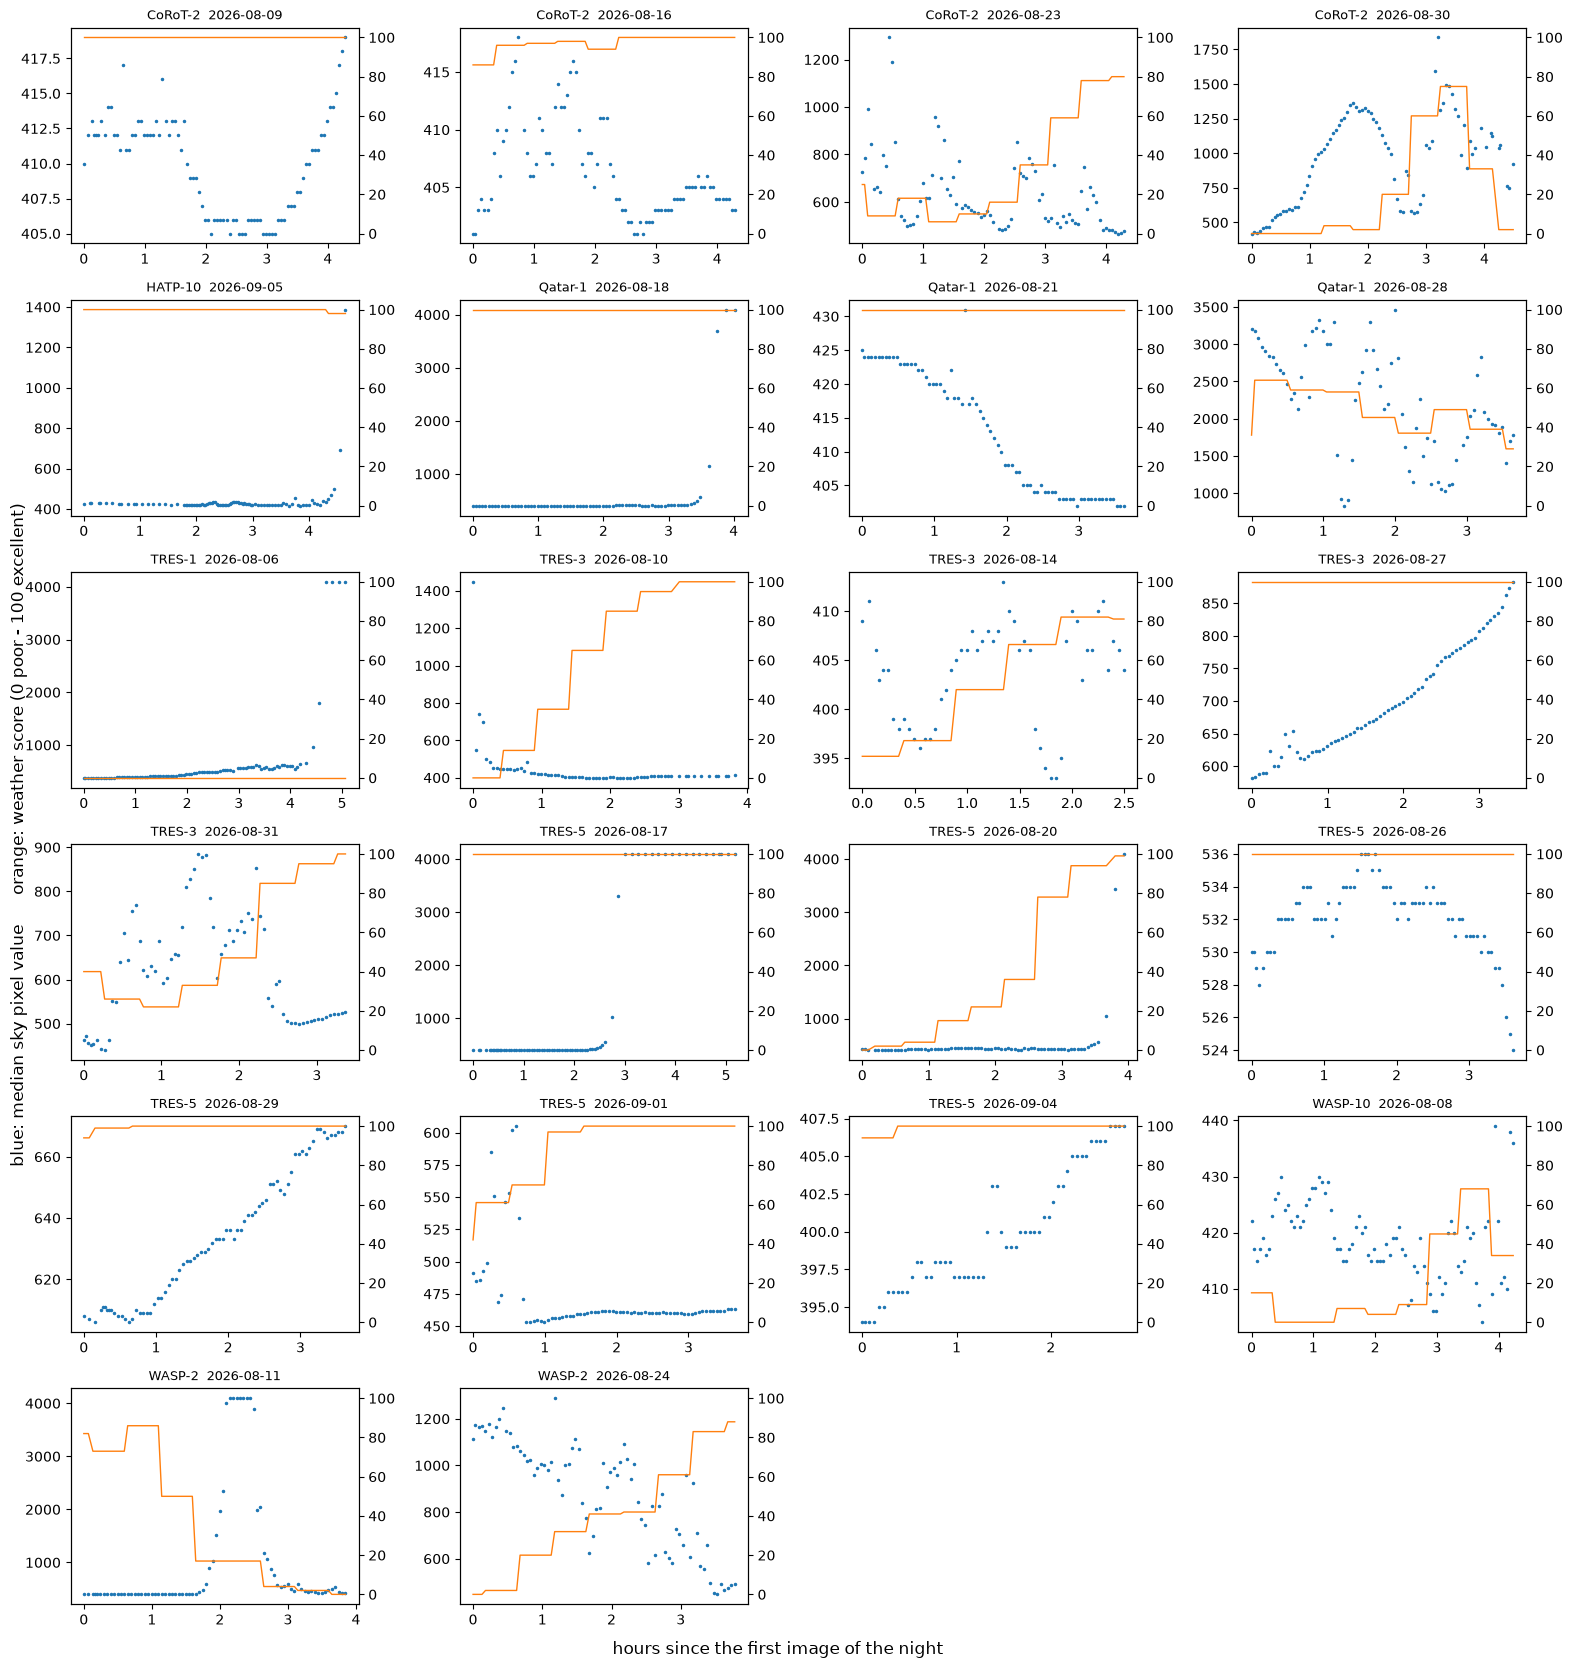

In [35]:
# Step 7c: sky brightness and weather score during each night
groups = list(frames.groupby(["target", "night"]))
n_cols = 4
n_rows = int(np.ceil(len(groups) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.8 * n_rows))

for ax, ((target, night), g) in zip(axes.flat, groups):
    hours = (g["mjd"] - g["mjd"].min()) * 24
    ax.plot(hours, g["sky_median"], ".", ms=3, color="tab:blue")
    ax.set_title(f"{target}  {night}", fontsize=9)
    ax_weather = ax.twinx()                      # second y-axis on the right
    ax_weather.plot(hours, g["weather"], color="tab:orange", lw=1)
    ax_weather.set_ylim(-5, 105)

for ax in axes.flat[len(groups):]:
    ax.axis("off")                               # hide empty panels

fig.supxlabel("hours since the first image of the night")
fig.supylabel("blue: median sky pixel value      orange: weather score (0 poor - 100 excellent)")
plt.tight_layout()
plt.show()

## Step 8 — Data quality problems we found

Cleaning and preparing data is **15% of the score**. The jury will ask: *"What was the most important problem in the data?"* and *"What changed during cleaning?"*
Each cell below proves one problem with code.

In [38]:
# Problem 1: the provided index file has an empty exposure column and Windows-only paths
old_index = pd.read_csv(DATA_DIR / "dataset_index.csv")
print("Rows in dataset_index.csv:          ", len(old_index))
print("Empty values in 'exposure' column:  ", old_index["exposure"].isna().sum())
print("Paths written with Windows '\\':      ", old_index["relative_path"].str.contains("\\", regex=False).sum())

# Why? index.py asks the header for "EXPOSURE", but the real key is "EXPTIME"
print("\n'EXPOSURE' in header:", "EXPOSURE" in header, "   'EXPTIME' in header:", "EXPTIME" in header)

Rows in dataset_index.csv:           1741
Empty values in 'exposure' column:   1741
Paths written with Windows '\':       1741

'EXPOSURE' in header: False    'EXPTIME' in header: True


In [39]:
# Problem 2: the README says Dark, Bias and Flat calibration images exist — which types are really there?
calibration_types = meta.loc[meta["is_calibration"], "filename"].str.split("-").str[0].value_counts()
calibration_types

filename
Dark    60
Name: count, dtype: int64

In [41]:
# Problem 3: the time number in the header (MJD-OBS) is rounded to 0.001 day = 86.4 seconds
difference_seconds = (frames["mjd"] - frames["mjd_header"]) * 86400
print(difference_seconds.abs().describe().round(1))
print("\nDecision: use UT-OBS (millisecond precision) for all timing, not MJD-OBS.")

count    1681.0
mean       21.4
std        12.5
min         0.6
25%         9.5
50%        20.8
75%        31.8
max        43.1
dtype: float64

Decision: use UT-OBS (millisecond precision) for all timing, not MJD-OBS.


In [42]:
# Problem 4: star names in the data are not the official catalog names
# We need the official names to look the planets up in the NASA Exoplanet Archive.
OFFICIAL_NAMES = {
    "CoRoT-2": "CoRoT-2",
    "HATP-10": "HAT-P-10",   # also known as WASP-11 (found by two teams)
    "Qatar-1": "Qatar-1",
    "TRES-1":  "TrES-1",
    "TRES-3":  "TrES-3",
    "TRES-5":  "TrES-5",
    "WASP-10": "WASP-10",
    "WASP-2":  "WASP-2",
}
frames["official_name"] = frames["target"].map(OFFICIAL_NAMES)
print("Targets without an official name:", frames["official_name"].isna().sum())
frames[["target", "official_name"]].drop_duplicates().reset_index(drop=True)

Targets without an official name: 0


,target,official_name
0,CoRoT-2,CoRoT-2
1,HATP-10,HAT-P-10
2,Qatar-1,Qatar-1
3,TRES-1,TrES-1
4,TRES-3,TrES-3
5,TRES-5,TrES-5
6,WASP-10,WASP-10
7,WASP-2,WASP-2


In [43]:
# Problem 5: frames with difficult observing conditions
# We FLAG these frames instead of deleting them, so later we can measure their effect.
frames["flag_low_altitude"] = frames["altitude_deg"] < 30   # below 30 degrees the light crosses 2x more air
frames["flag_poor_weather"] = frames["weather"] < 50
frames["flag_saturated"] = frames["n_saturated"] > 0        # some pixel hit 4095 (could be any star, checked later)
frames["flag_bright_sky"] = frames["sky_median"] >= 1000    # normal sky is ~400: dawn, moonlight or lit clouds

flag_columns = ["flag_low_altitude", "flag_poor_weather", "flag_saturated", "flag_bright_sky"]
print(frames[flag_columns].sum().rename("frames flagged"))
print("Frames where the whole sky is at the camera limit (unusable):", (frames["sky_median"] >= 4000).sum())
print("\nFlagged frames per target:")
frames.groupby("target")[flag_columns].sum()

flag_low_altitude     134
flag_poor_weather     594
flag_saturated       1096
flag_bright_sky       200
Name: frames flagged, dtype: int64
Frames where the whole sky is at the camera limit (unusable): 33

Flagged frames per target:


,flag_low_altitude,flag_poor_weather,flag_saturated,flag_bright_sky
target,,,,
CoRoT-2,8,128,148,47
HATP-10,0,0,93,1
Qatar-1,11,43,216,74
TRES-1,33,91,4,5
TRES-3,37,104,162,1
TRES-5,40,53,374,23
WASP-10,0,76,26,0
WASP-2,5,99,73,49


In [44]:
# Problem 6: the data is unbalanced between stars
print(per_target["nights"].rename("nights per star"))
print("\nSome stars have 6 nights, others only 1. When we split data into training and testing,")
print("we must split by NIGHT (not by image), and results for stars with 1 night will be less certain.")

target
TRES-5     6
CoRoT-2    4
TRES-3     4
Qatar-1    3
WASP-2     2
HATP-10    1
TRES-1     1
WASP-10    1
Name: nights per star, dtype: int64

Some stars have 6 nights, others only 1. When we split data into training and testing,
we must split by NIGHT (not by image), and results for stars with 1 night will be less certain.


In [45]:
# Problem 7: some nights are cloudy — count the stars visible in the middle image of every night
# DAOStarFinder looks for small, round, bright spots that clearly stand out from the background noise.
import warnings
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

star_counts = []
for (target, night), g in frames.groupby(["target", "night"]):
    middle = g.iloc[len(g) // 2]
    img = fits.getdata(DATA_DIR / middle["path"]).astype(float) - load_dark(night)
    _, background, noise = sigma_clipped_stats(img, sigma=3)   # typical background level and noise size
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                         # hide the "no stars found" warning on cloudy nights
        stars = DAOStarFinder(fwhm=2.5, threshold=10 * noise)(img - background)
    star_counts.append({"target": target, "night": night,
                        "weather": middle["weather"],
                        "sky_median": middle["sky_median"],
                        "stars_found": 0 if stars is None else len(stars)})

star_counts = pd.DataFrame(star_counts).sort_values("stars_found").reset_index(drop=True)
star_counts

,target,night,weather,sky_median,stars_found
0,WASP-2,2026-08-11,17,1512.0,0
1,CoRoT-2,2026-08-23,16,515.0,1
2,Qatar-1,2026-08-28,45,2444.0,1
3,TRES-1,2026-08-06,0,481.0,1
4,WASP-10,2026-08-08,4,415.0,2
5,CoRoT-2,2026-08-30,2,1228.0,4
6,WASP-2,2026-08-24,41,1009.0,12
7,TRES-3,2026-08-31,33,719.0,27
8,TRES-5,2026-08-20,22,440.0,35
9,TRES-3,2026-08-27,100,681.0,111


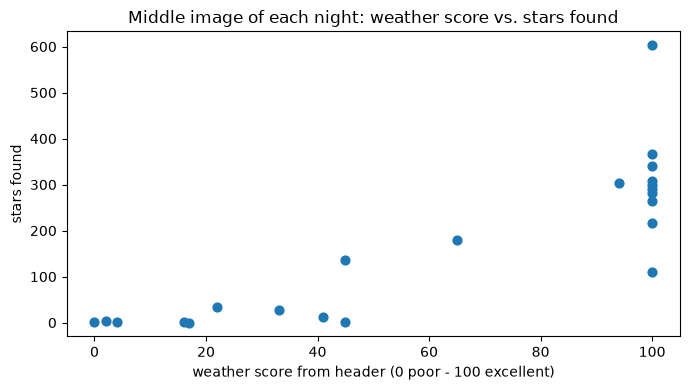

In [46]:
# Problem 7 (chart): does the header weather score agree with the number of stars we can see?
ax = star_counts.plot.scatter(x="weather", y="stars_found", figsize=(7, 4), s=40)
ax.set_title("Middle image of each night: weather score vs. stars found")
ax.set_xlabel("weather score from header (0 poor - 100 excellent)")
ax.set_ylabel("stars found")
plt.tight_layout()
plt.show()

### What Problem 7 tells us

Nights with only a handful of stars were mostly covered by clouds. We cannot measure a transit there.
But they are still useful: a cloud makes the star look dimmer for a while, which is exactly the kind of **false positive** our AI must learn to reject.

## Step 9 — Save the clean index

We save one clean table (`outputs/frames_index.csv`) that the next notebooks will use instead of the broken `dataset_index.csv`.

In [47]:
# Step 9: save the clean table
frames.to_csv(OUTPUT_DIR / "frames_index.csv", index=False)
nights.to_csv(OUTPUT_DIR / "nights_summary.csv")
star_counts.to_csv(OUTPUT_DIR / "night_star_counts.csv", index=False)
print("saved:", OUTPUT_DIR / "frames_index.csv", "->", frames.shape)
print("saved:", OUTPUT_DIR / "nights_summary.csv", "->", nights.shape)

saved: ../outputs/frames_index.csv -> (1681, 19)
saved: ../outputs/nights_summary.csv -> (22, 9)


## Try it yourself (Mostafa & Sara)

1. In Step 5a add the line `sample_path = science_files[900]` at the end of the cell, then run Steps 5 and 6 again. Which star is it? What are its weather score and altitude? Can you see stars after the dark is subtracted?
2. Using the `nights` table, which night has the **worst** average weather and which has the **best**? (Hint: `nights.sort_values("weather_mean")`)
3. Plot `altitude_deg` against `mjd` for the TRES-1 night. What happens to the star during the night, and why could that fake a dip?
4. Research task: open the [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu) and search each official name. Write down the **orbital period** and **transit duration** of each planet. We will need them in notebook 03.

In [ ]:
# Your experiments here


## Decision log (copy these into the README later)

| # | Decision | Reason |
|---|---|---|
| 1 | Build our own index (`frames_index.csv`) instead of `dataset_index.csv` | Provided index has empty exposure values (`EXPOSURE` vs `EXPTIME` bug) and Windows-only paths |
| 2 | Use `UT-OBS` for time, not `MJD-OBS` | `MJD-OBS` is rounded to 86.4 s |
| 3 | Map folder names to official catalog names | Needed to query the NASA Exoplanet Archive |
| 4 | Flag difficult frames, do not delete them | Lets us measure their effect on false positives later |
| 5 | Calibration uses dark frames only | No bias or flat frames exist in the dataset, despite the README |
| 6 | Subtract the median of the 2 darks from the same (or closest) date | Raw images contain the camera's own signal (a brightness gradient); it must be removed before measuring star brightness |
| 7 | Treat nights with very few visible stars as cloudy | Star count in the middle image agrees with the header weather score; to be confirmed image-by-image in notebook 02 |

**Next notebook:** `02_photometry.ipynb` — measure the brightness of the target star and comparison stars in every image and draw our first light curve.